In [1]:
# Cell 1 — Setup
import sys
for mod in list(sys.modules.keys()):
    if mod in ('config','data_loader','preprocessor','trainer','evaluator'):
        del sys.modules[mod]
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

from data_loader import (load_raw_data, clean_dependents,
                          handle_credit_history, encode_target,
                          get_X_y, get_train_val_split)
from trainer     import train_all_models
from evaluator   import (evaluate_all_models, plot_confusion_matrices,
                          plot_roc_curves, plot_metric_comparison,
                          cross_validate_all_models, find_optimal_threshold)

df, _ = load_raw_data()
df    = clean_dependents(df)
df    = handle_credit_history(df)
df    = encode_target(df)
X, y  = get_X_y(df)
X_train, X_val, y_train, y_val = get_train_val_split(X, y)

print("Data ready.")

Data ready.


In [2]:
# Cell 2 — Train and single-split evaluate
print("Training models...")
fitted_pipelines = train_all_models(X_train, y_train)

results_df = evaluate_all_models(fitted_pipelines, X_val, y_val)
print("\n── Single-split results ──")
print(results_df.to_string())

Training models...
  Training LogisticRegression... done
  Training DecisionTree... done
  Training RandomForest... done
  Training GradientBoosting... done
  Training XGBoost... done

── Single-split results ──
                    accuracy  precision  recall      f1  roc_auc
model                                                           
RandomForest          0.8455     0.8438  0.9529  0.8950   0.8214
DecisionTree          0.8130     0.8229  0.9294  0.8729   0.7746
XGBoost               0.7886     0.8172  0.8941  0.8539   0.7731
GradientBoosting      0.8374     0.8351  0.9529  0.8901   0.7557
LogisticRegression    0.6748     0.7027  0.9176  0.7959   0.7412


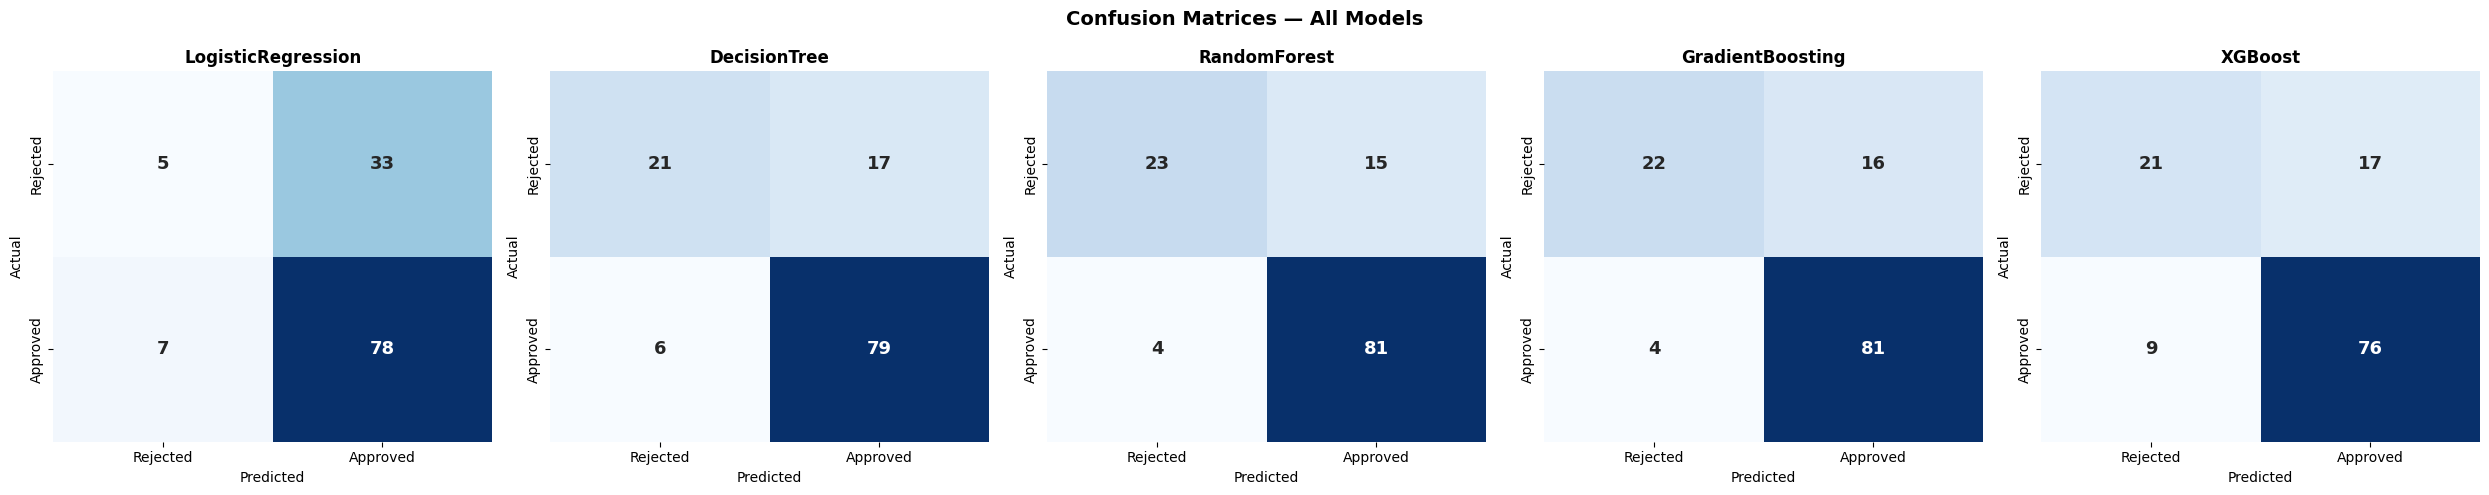

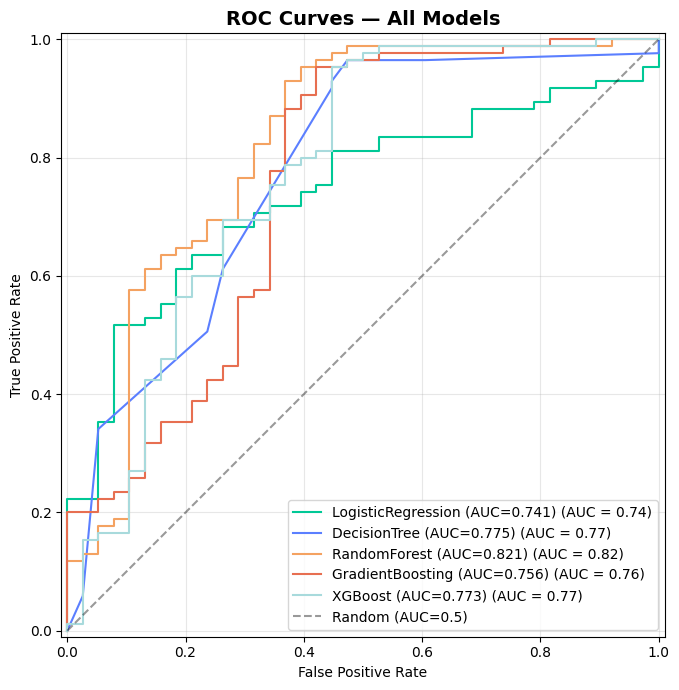

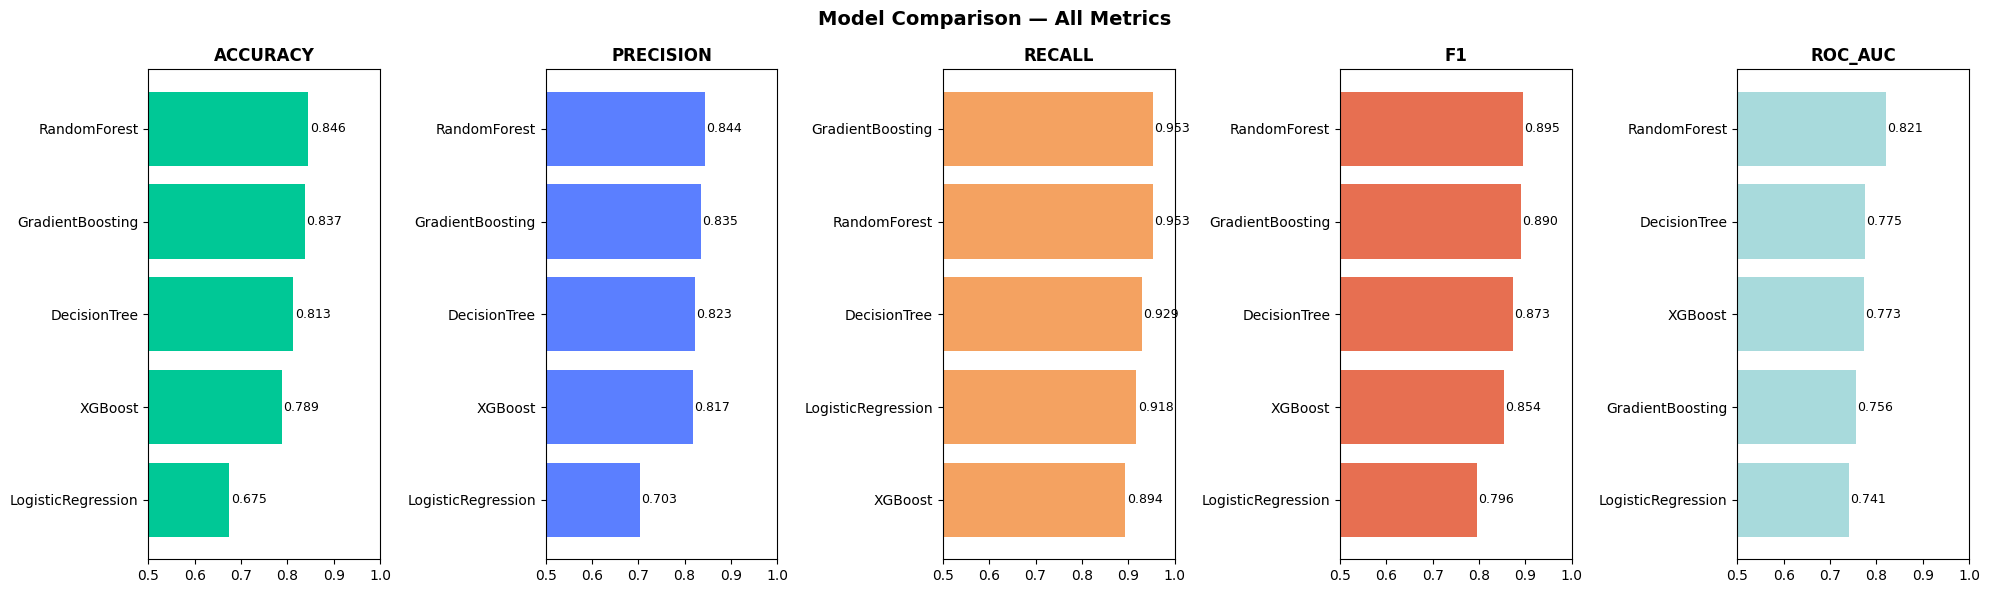

In [3]:
# Cell 3 — Confusion matrices + ROC curves
plot_confusion_matrices(fitted_pipelines, X_val, y_val)
plot_roc_curves(fitted_pipelines, X_val, y_val)
plot_metric_comparison(results_df)

In [4]:
# Cell 4 — Cross-validation (honest evaluation)
print("Running 5-fold cross-validation...")
cv_results = cross_validate_all_models(X_train, y_train)

print("\n── Cross-validation results ──")
print(cv_results[['cv_roc_auc','cv_roc_auc_std',
                   'train_roc_auc','overfit_gap']].to_string())

print("\nKey checks:")
print("  overfit_gap > 0.05 → overfitting → needs regularisation")
print("  cv_roc_auc_std > 0.03 → unstable across folds")

Running 5-fold cross-validation...
  Cross-validating LogisticRegression... done
  Cross-validating DecisionTree... done
  Cross-validating RandomForest... done
  Cross-validating GradientBoosting... done
  Cross-validating XGBoost... done

── Cross-validation results ──
                    cv_roc_auc  cv_roc_auc_std  train_roc_auc  overfit_gap
model                                                                     
RandomForest            0.7659          0.0757         0.9957       0.2298
XGBoost                 0.7422          0.0876         0.9922       0.2500
GradientBoosting        0.7362          0.0744         0.9893       0.2531
DecisionTree            0.7225          0.0421         0.8305       0.1080
LogisticRegression      0.6880          0.1066         0.7299       0.0419

Key checks:
  overfit_gap > 0.05 → overfitting → needs regularisation
  cv_roc_auc_std > 0.03 → unstable across folds


Best model: RandomForest (AUC 0.8214)
Finding optimal threshold...



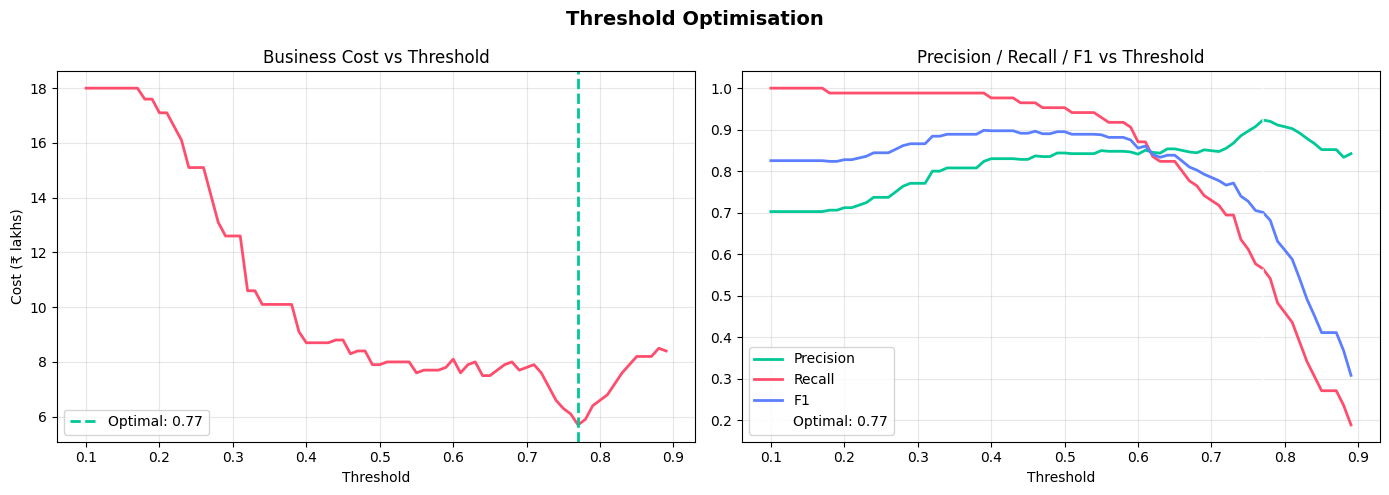


Optimal threshold : 0.77
Minimum cost      : ₹570,000
Precision         : 0.923
Recall            : 0.565
F1                : 0.701


In [5]:
# Cell 5 — Threshold optimisation on best model
best_name     = results_df['roc_auc'].idxmax()
best_pipeline = fitted_pipelines[best_name]

print(f"Best model: {best_name} (AUC {results_df.loc[best_name,'roc_auc']})")
print("Finding optimal threshold...\n")

threshold_result = find_optimal_threshold(
    best_pipeline, X_val, y_val,
    fp_cost=50_000,
    fn_cost=10_000
)